# 09 — Subtype-adjusted multi-omic discovery

This notebook performs exploratory multi-omic discovery analyses in TCGA-BRCA.

The goal is to move beyond known positive controls and search for less obvious subtype-adjusted associations between copy-number alterations, driver events and gene expression.

The analyses are hypothesis-generating and do not imply causality or clinical validation.

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr
from scipy.stats import t as t_dist
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform

pd.set_option("display.max_columns", 100)
sns.set_context("notebook")

In [2]:
PROJECT_ROOT = Path("..").resolve()

RAW_MULTIOMICS_DIR = PROJECT_ROOT / "data" / "raw" / "cbioportal_brca_multiomics"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "results" / "figures"
TABLES_DIR = PROJECT_ROOT / "results" / "tables"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

expression_path = PROCESSED_DIR / "expression_rsem_samples_by_gene.tsv"
driver_path = PROCESSED_DIR / "multiomics_driver_alteration_table.tsv"
cna_path = RAW_MULTIOMICS_DIR / "data_cna.txt"

print("Expression exists:", expression_path.exists())
print("Driver table exists:", driver_path.exists())
print("CNA exists:", cna_path.exists())

Expression exists: True
Driver table exists: True
CNA exists: True


In [3]:
expression = pd.read_csv(expression_path, sep="\t")
driver_table = pd.read_csv(driver_path, sep="\t")
cna_raw = pd.read_csv(cna_path, sep="\t", comment="#", low_memory=False)

print("expression:", expression.shape)
print("driver_table:", driver_table.shape)
print("cna_raw:", cna_raw.shape)

display(expression.head())
display(driver_table.head())
display(cna_raw.head())

expression: (1082, 20514)
driver_table: (1082, 55)
cna_raw: (25128, 1072)


,SAMPLE_ID_ORIGINAL,SAMPLE_ID_15,PATIENT_ID_12,A1BG,A1CF,A2BP1,A2LD1,A2M,A2M-AS1,A2ML1,A4GALT,A4GNT,AAA1,AAAS,AACS,AACSL,AADAC,AADACL2,AADACL3,AADACL4,AADACP1,AADAT,AAGAB,AAK1,AAMP,AANAT,AARS,AARS2,AARSD1,AASDH,AASDHPPT,AASS,AATBC,AATF,AATK,ABAT,ABCA1,ABCA10,ABCA11P,ABCA12,ABCA13,ABCA17P,ABCA2,ABCA3,ABCA4,ABCA5,ABCA6,ABCA7,ABCA8,ABCA9,...,ZNRF2,ZNRF2P1,ZNRF3,ZNRF4,ZP1,ZP2,ZP3,ZP4,ZPBP,ZPBP2,ZPLD1,ZRANB1,ZRANB2,ZRANB3,ZRSR2,ZSCAN1,ZSCAN10,ZSCAN12,ZSCAN12P1,ZSCAN16,ZSCAN18,ZSCAN2,ZSCAN20,ZSCAN21,ZSCAN22,ZSCAN23,ZSCAN29,ZSCAN4,ZSCAN5A,ZSCAN5B,ZSWIM1,ZSWIM2,ZSWIM3,ZSWIM4,ZSWIM5,ZSWIM6,ZSWIM7,ZUFSP,ZW10,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3,psiTPTE22
0,TCGA-3C-AAAU-01,TCGA-3C-AAAU-01,TCGA-3C-AAAU,197.090,0.0000,0.0000,102.9630,5798.37,32.2187,1.3786,68.2424,8.6165,0.3447,649.337,1087.400,1.3786,0.0000,0.0,0.0000,0.0,0.0000,5.5145,1300.40,517.333,2053.13,0.3447,4409.56,689.897,466.668,277.450,808.914,45.8396,111.6690,1518.91,619.5930,620.731,288.462,16.2334,79.1509,321.2220,0.0000,17.9223,4507.450,5470.770,3.7912,795.093,23.0921,596.9490,58.5920,37.5678,...,414.969,76.1696,741.706,0.0,3.7912,0.0000,411.791,0.0000,1.034,0.3447,53.7668,879.225,2504.080,72.0337,421.862,0.3447,2.7573,141.6550,128.1790,225.062,132.349,582.473,158.8880,253.510,300.887,38.2571,960.220,0.3447,32.3979,1.0340,431.513,0.3447,180.2570,489.416,454.9500,621.764,194.108,89.956,430.824,415.824,931.957,129.5920,1007.780,1658.500,258.4940,1208.370,3507.25,1894.930,1180.460,1.7233
1,TCGA-3C-AALI-01,TCGA-3C-AALI-01,TCGA-3C-AALI,237.384,0.0000,0.0000,70.8646,7571.98,29.9782,4.3502,157.6940,0.5438,0.0000,887.983,836.324,35.3453,1.0875,0.0,0.0000,0.0,0.0000,24.4698,3541.05,848.287,2979.88,2.1751,4570.96,472.501,418.706,184.339,678.630,71.7781,13.5943,7649.27,107.6670,240.348,421.930,17.9445,96.0903,678.6300,1.6313,70.6906,2330.070,2656.880,45.1332,388.798,25.0136,763.4580,20.1196,46.2208,...,841.218,39.6955,373.573,0.0,30.4513,4.3502,439.222,0.5438,0.000,2.1751,3.2626,566.068,627.656,62.5340,349.647,18.4883,0.0000,91.8978,58.2164,174.551,1549.760,236.542,27.7325,698.521,197.390,7.0691,588.363,0.0000,127.7870,4.3502,507.341,0.0000,139.2060,475.802,113.6490,242.523,217.134,105.492,340.402,1161.330,965.198,59.8151,448.613,1343.120,198.4770,603.589,5504.62,1318.650,406.743,926.5910
2,TCGA-3C-AALJ-01,TCGA-3C-AALJ-01,TCGA-3C-AALJ,423.237,0.9066,0.0000,161.2600,8840.40,17.2620,0.0000,573.8890,0.0000,0.0000,723.481,1533.090,2.7199,0.9066,0.0,1.8132,0.0,1.8132,53.4905,1360.83,568.450,2291.93,1.8132,2556.66,439.710,390.752,190.390,779.692,76.1559,20.8522,2097.91,145.0590,375.340,689.882,27.1985,156.0200,0.0000,0.9066,12.6927,3208.520,1514.050,1.8132,559.384,81.5956,383.5000,52.5839,54.3971,...,266.546,38.9846,257.480,0.0,2.7199,0.0000,334.506,0.0000,0.000,0.0000,117.8600,1125.110,1951.210,35.3581,470.535,112.4210,0.0000,99.7280,38.2684,110.607,2225.750,268.359,52.5839,282.865,138.713,46.2375,514.053,0.0000,62.5567,0.0000,352.675,0.0000,81.5956,485.947,180.4170,506.800,164.234,235.721,304.624,305.422,2531.280,35.3581,533.998,768.812,331.8220,532.185,5458.75,942.883,509.519,35.3581
3,TCGA-3C-AALK-01,TCGA-3C-AALK-01,TCGA-3C-AALK,191.018,0.0000,0.0000,62.5072,10960.20,17.8527,1.6549,506.4130,0.0000,0.0000,776.996,858.088,0.0000,2.8962,0.0,0.0000,0.0,1.2412,57.0956,1683.49,727.762,2762.52,0.4137,2122.88,431.936,493.587,196.525,665.288,183.2850,38.8912,1915.18,119.9840,1721.560,749.264,23.5830,137.3230,1430.7000,2.4824,9.1022,1375.260,968.556,73.2313,412.081,78.1961,465.8670,213.4880,70.3351,...,632.602,50.0621,330.161,0.0,1.2412,1.6549,127.017,0.4137,0.000,0.0000,9.1022,780.306,1195.830,61.2329,364.501,6.2060,0.8275,211.8330,33.4506,163.012,1276.380,304.923,36.8225,300.625,122.466,26.4791,409.185,0.4137,57.5093,0.8275,286.305,0.0000,67.0252,626.396,107.5710,340.505,196.136,148.531,314.026,394.506,668.597,55.0269,437.733,863.881,175.4240,607.365,5691.35,781.134,700.869,66.6115
4,TCGA-4H-AAAK-01,TCGA-4H-AAAK-01,TCGA-4H-AAAK,268.881,0.4255,3.8298,154.3700,9585.44,31.5787

,SAMPLE_ID_15,PATIENT_ID_12,SUBTYPE,TP53_mut,PIK3CA_mut,GATA3_mut,CDH1_mut,MAP3K1_mut,BRCA1_mut,BRCA2_mut,ERBB2_mut,MYC_mut,CCND1_mut,PTEN_mut,AKT1_mut,RB1_mut,TP53_amp,PIK3CA_amp,GATA3_amp,CDH1_amp,MAP3K1_amp,BRCA1_amp,BRCA2_amp,ERBB2_amp,MYC_amp,CCND1_amp,PTEN_amp,AKT1_amp,RB1_amp,TP53_del,PIK3CA_del,GATA3_del,CDH1_del,MAP3K1_del,BRCA1_del,BRCA2_del,ERBB2_del,MYC_del,CCND1_del,PTEN_del,AKT1_del,RB1_del,TP53_any_alt,PIK3CA_any_alt,GATA3_any_alt,CDH1_any_alt,MAP3K1_any_alt,BRCA1_any_alt,BRCA2_any_alt,ERBB2_any_alt,MYC_any_alt,CCND1_any_alt,PTEN_any_alt,AKT1_any_alt,RB1_any_alt
0,TCGA-3C-AAAU-01,TCGA-3C-AAAU,BRCA_LumA,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0
1,TCGA-3C-AALI-01,TCGA-3C-AALI,BRCA_Her2,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
2,TCGA-3C-AALJ-01,TCGA-3C-AALJ,BRCA_LumB,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,1,0,0,0,0
3,TCGA-3C-AALK-01,TCGA-3C-AALK,BRCA_LumA,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0
4,TCGA-4H-AAAK-01,TCGA-4H-AAAK,BRCA_LumA,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0


,Hugo_Symbol,Entrez_Gene_Id,TCGA-3C-AAAU-01,TCGA-3C-AALI-01,TCGA-3C-AALJ-01,TCGA-3C-AALK-01,TCGA-4H-AAAK-01,TCGA-5L-AAT0-01,TCGA-5T-A9QA-01,TCGA-A1-A0SB-01,TCGA-A1-A0SD-01,TCGA-A1-A0SE-01,TCGA-A1-A0SF-01,TCGA-A1-A0SG-01,TCGA-A1-A0SH-01,TCGA-A1-A0SI-01,TCGA-A1-A0SJ-01,TCGA-A1-A0SK-01,TCGA-A1-A0SM-01,TCGA-A1-A0SN-01,TCGA-A1-A0SO-01,TCGA-A1-A0SP-01,TCGA-A1-A0SQ-01,TCGA-A2-A04N-01,TCGA-A2-A04P-01,TCGA-A2-A04Q-01,TCGA-A2-A04R-01,TCGA-A2-A04T-01,TCGA-A2-A04U-01,TCGA-A2-A04V-01,TCGA-A2-A04W-01,TCGA-A2-A04X-01,TCGA-A2-A04Y-01,TCGA-A2-A0CK-01,TCGA-A2-A0CL-01,TCGA-A2-A0CM-01,TCGA-A2-A0CO-01,TCGA-A2-A0CP-01,TCGA-A2-A0CQ-01,TCGA-A2-A0CR-01,TCGA-A2-A0CS-01,TCGA-A2-A0CT-01,TCGA-A2-A0CU-01,TCGA-A2-A0CV-01,TCGA-A2-A0CW-01,TCGA-A2-A0CX-01,TCGA-A2-A0D0-01,TCGA-A2-A0D1-01,TCGA-A2-A0D2-01,TCGA-A2-A0D3-01,...,TCGA-OL-A5D6-01,TCGA-OL-A5D7-01,TCGA-OL-A5D8-01,TCGA-OL-A5DA-01,TCGA-OL-A5RU-01,TCGA-OL-A5RV-01,TCGA-OL-A5RW-01,TCGA-OL-A5RX-01,TCGA-OL-A5RY-01,TCGA-OL-A5RZ-01,TCGA-OL-A5S0-01,TCGA-OL-A66H-01,TCGA-OL-A66I-01,TCGA-OL-A66J-01,TCGA-OL-A66K-01,TCGA-OL-A66L-01,TCGA-OL-A66N-01,TCGA-OL-A66O-01,TCGA-OL-A66P-01,TCGA-OL-A6VO-01,TCGA-OL-A6VQ-01,TCGA-OL-A6VR-01,TCGA-OL-A97C-01,TCGA-PE-A5DC-01,TCGA-PE-A5DD-01,TCGA-PE-A5DE-01,TCGA-PL-A8LV-01,TCGA-PL-A8LX-01,TCGA-PL-A8LY-01,TCGA-PL-A8LZ-01,TCGA-S3-A6ZF-01,TCGA-S3-A6ZG-01,TCGA-S3-A6ZH-01,TCGA-S3-AA0Z-01,TCGA-S3-AA10-01,TCGA-S3-AA11-01,TCGA-S3-AA12-01,TCGA-S3-AA14-01,TCGA-S3-AA15-01,TCGA-S3-AA17-01,TCGA-UL-AAZ6-01,TCGA-UU-A93S-01,TCGA-V7-A7HQ-01,TCGA-W8-A86G-01,TCGA-WT-AB41-01,TCGA-WT-AB44-01,TCGA-XX-A899-01,TCGA-XX-A89A-01,TCGA-Z7-A8R5-01,TCGA-Z7-A8R6-01
0,ACAP3,116983.0,0,-1,-1,0,0,0,-1,0,-1,0,0,0,-1,0,0,1,-1,-1,-1,1,0,0,1,0,-1,0,1,0,1,-1,1,0,0,1,0,0,0,0,-1,-1,0,0,-1,-1,1,0,0,0,...,0,0,0,0,0,0,1,0,0,-1,-1,0,1,-2,-1,0,-1,0,0,1,0,0,-2,-1,-1,0,1,-1,0,1,-1,-1,-1,0,0,0,0,0,0,-1,0,-1,0,0,-1,-1,0,-1,-1,0
1,ACTRT2,140625.0,0,-1,-1,0,0,0,-1,0,-1,0,0,0,-1,0,0,1,-1,-1,-1,1,0,0,1,0,-1,0,1,0,1,-1,1,0,0,1,0,0,0,0,-1,-1,0,0,-1,-1,1,0,0,0,...,0,0,0,0,0,0,1,0,0,-1,-1,0,1,-2,-1,0,-1,0,0,1,0,0,-2,-1,-1,0,1,-1,0,1,-1,-1,-1,0,0,0,0,0,0,-1,0,-1,0,0,-1,-1,0,-1,-1,0
2,AGRN,375790.0,0,-1,-1,0,0,0,-1,0,-1,0,0,0,-1,0,0,1,-1,-1,-1,1,0,0,1,0,-1,0,1,0,1,-1,1,0,0,1,0,0,0,0,-1,-1,0,0,-1,-1,1,0,0,0,...,0,0,0,0,0,0,1,0,0,-1,-1,0,1,-2,-1,0,-1,0,0,1,0,0,-2,-1,-1,0,1,-1,0,1,-1,-1,-1,0,0,0,0,0,0,-1,0,-1,0,0,-1,-1,0,-1,-1,0
3,ANKRD65,441869.0,0,-1,-1,0,0,0,-1,0,-1,0,0,0,-1,0,0,1,-1,-1,-1,1,0,0,1,0,-1,0,1,0,1,-1,1,0,0,1,0,0,0,0,-1,-1,0,0,-1,-1,1,0,0,0,...,0,0,0,0,0,0,1,0,0,-1,-1,0,1,-2,-1,0,-1,0,0,1,0,0,-2,-1,-1,0,1,-1,0,1,-1,-1,-1,0,0,0,0,0,0,-1,0,-1,0,0,-1,-1,0,-1,-1,0
4,ATAD3A,55210.0,0,-1,-1,0,0,0,-1,0,-1,0,0,0,-1,0,0,1,-1,-1,-1,1,0,0,1,0,-1,0,1,0,1,-1,1,0,0,1,0,0,0,0,-1,-1,0,0,-1,-1,1,0,0,0,...,0,0,0,0,0,0,1,0,0,-1,-1,0,1,-2,-1,0,-1,0,0,1,0,0,-2,-1,-1,0,1,-1,0,1,-1,-1,-1,0,0,0,0,0,0,-1,0,-1,0,0,-1,-1,0,-1,-1,0


In [4]:
metadata_cols = [col for col in ["Hugo_Symbol", "Entrez_Gene_Id"] if col in cna_raw.columns]
sample_cols = [col for col in cna_raw.columns if col not in metadata_cols]

cna_numeric = cna_raw.copy()

for col in sample_cols:
    cna_numeric[col] = pd.to_numeric(cna_numeric[col], errors="coerce")

cna_gene_by_sample = (
    cna_numeric
    .groupby("Hugo_Symbol")[sample_cols]
    .median()
)

cna_sample_by_gene = cna_gene_by_sample.T
cna_sample_by_gene.index.name = "SAMPLE_ID_ORIGINAL"
cna_sample_by_gene = cna_sample_by_gene.reset_index()

cna_sample_by_gene["SAMPLE_ID_15"] = cna_sample_by_gene["SAMPLE_ID_ORIGINAL"].astype(str).str[:15]
cna_sample_by_gene["PATIENT_ID_12"] = cna_sample_by_gene["SAMPLE_ID_ORIGINAL"].astype(str).str[:12]

print("cna_sample_by_gene:", cna_sample_by_gene.shape)
display(cna_sample_by_gene.head())

cna_sample_by_gene: (1070, 25090)


Hugo_Symbol,SAMPLE_ID_ORIGINAL,A1BG,A1BG-AS1,A1CF,A2M,A2M-AS1,A2ML1,A2MP1,A3GALT2,A4GALT,A4GNT,AA06,AAAS,AACS,AACSP1,AADAC,AADACL2,AADACL2-AS1,AADACL3,AADACL4,AADACP1,AADAT,AAED1,AAGAB,AAK1,AAMDC,AAMP,AANAT,AAR2,AARD,AARS,AARS2,AARSD1,AASDH,AASDHPPT,AASS,AATBC,AATF,AATK,AATK-AS1,ABAT,ABCA1,ABCA10,ABCA11P,ABCA12,ABCA13,ABCA17P,ABCA2,ABCA3,ABCA4,...,hsa-mir-548h-2,hsa-mir-548h-3,hsa-mir-548h-4,hsa-mir-548i-4,hsa-mir-548l,hsa-mir-548m,hsa-mir-548n,hsa-mir-548o,hsa-mir-548p,hsa-mir-548q,hsa-mir-548s,hsa-mir-548t,hsa-mir-548u,hsa-mir-548v,hsa-mir-548w,hsa-mir-548x,hsa-mir-551a,hsa-mir-552,hsa-mir-562,hsa-mir-566,hsa-mir-571,hsa-mir-576,hsa-mir-579,hsa-mir-582,hsa-mir-584,hsa-mir-587,hsa-mir-588,hsa-mir-606,hsa-mir-607,hsa-mir-616,hsa-mir-619,hsa-mir-625,hsa-mir-633,hsa-mir-640,hsa-mir-643,hsa-mir-646,hsa-mir-649,hsa-mir-652,hsa-mir-664,hsa-mir-720,hsa-mir-886,hsa-mir-887,hsa-mir-924,hsa-mir-941-1,hsa-mir-941-2,hsa-mir-941-3,hsa-mir-95,hsa-mir-96,SAMPLE_ID_15,PATIENT_ID_12
0,TCGA-3C-AAAU-01,0.0,0.0,-1.0,1.0,1.0,1.0,1.0,0.0,-1.0,1.0,0.0,-1.0,-1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,-1.0,-1.0,0.0,-1.0,2.0,-1.0,0.0,1.0,1.0,1.0,1.0,0.0,-1.0,-1.0,1.0,1.0,0.0,0.0,0.0,0.0,-1.0,0.0,-1.0,-1.0,1.0,0.0,-1.0,0.0,1.0,...,0.0,-1.0,1.0,-1.0,-1.0,-1.0,1.0,1.0,1.0,-1.0,-1.0,-1.0,1.0,1.0,0.0,1.0,0.0,0.0,-1.0,-1.0,-1.0,-1.0,1.0,1.0,1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,0.0,0.0,0.0,2.0,-1.0,-1.0,1.0,1.0,1.0,1.0,1.0,2.0,2.0,2.0,-1.0,1.0,TCGA-3C-AAAU-01,TCGA-3C-AAAU
1,TCGA-3C-AALI-01,0.0,0.0,-1.0,0.0,0.0,0.0,0.0,-1.0,-1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,-1.0,-1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,-1.0,-1.0,0.0,1.0,-1.0,1.0,1.0,1.0,0.0,0.0,-1.0,-1.0,0.0,1.0,0.0,1.0,0.0,-1.0,...,0.0,-1.0,1.0,-1.0,1.0,-1.0,1.0,1.0,-1.0,-1.0,1.0,0.0,1.0,1.0,0.0,-1.0,-1.0,-1.0,0.0,-1.0,-1.0,0.0,1.0,1.0,-1.0,-1.0,-1.0,-1.0,-1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,-1.0,1.0,1.0,-1.0,1.0,-1.0,1.0,1.0,1.0,-1.0,1.0,TCGA-3C-AALI-01,TCGA-3C-AALI
2,TCGA-3C-AALJ-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,-1.0,-1.0,-1.0,-1.0,1.0,0.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,1.0,-1.0,1.0,-1.0,-1.0,1.0,2.0,2.0,0.0,-1.0,-1.0,-1.0,-1.0,0.0,-1.0,2.0,1.0,1.0,0.0,1.0,2.0,-1.0,-1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,-1.0,-1.0,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,1.0,-1.0,1.0,-1.0,0.0,-1.0,-1.0,-1.0,-1.0,0.0,-1.0,-1.0,0.0,0.0,0.0,0.0,0.0,1.0,-1.0,0.0,1.0,-1.0,2.0,-1.0,0.0,1.0,-1.0,0.0,1.0,-1.0,0.0,0.0,1.0,2.0,2.0,2.0,-1.0,0.0,TCGA-3C-AALJ-01,TCGA-3C-AALJ
3,TCGA-3C-AALK-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,-1.0,0.0,-1.0,0.0,-1.0,0.0,0.0,1.0,2.0,2.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,-1.0,0.0,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,TCGA-3C-AALK-01,TCGA-3C-AALK
4,TCGA-4H-AAAK-01,1.0,1.0,0.0,-1.0,-1.0,-1.0,-1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-1.0,0.0,0.0,1.0,0.0,1.0,-1.0,0.0,1.0,0.0,-1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,-1.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,0.0,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,TCGA-4H-AAAK-01,TCGA-4H-AAAK


In [5]:
id_cols = ["SAMPLE_ID_15", "PATIENT_ID_12"]

expression_idx = expression.set_index(id_cols)
cna_idx = cna_sample_by_gene.set_index(id_cols)
meta_idx = driver_table.set_index(id_cols)

common_idx = expression_idx.index.intersection(cna_idx.index).intersection(meta_idx.index)

expression_idx = expression_idx.loc[common_idx].copy()
cna_idx = cna_idx.loc[common_idx].copy()
meta_idx = meta_idx.loc[common_idx].copy()

valid = meta_idx["SUBTYPE"].notna()

expression_idx = expression_idx.loc[valid].copy()
cna_idx = cna_idx.loc[valid].copy()
meta_idx = meta_idx.loc[valid].copy()

print("Aligned expression:", expression_idx.shape)
print("Aligned CNA:", cna_idx.shape)
print("Aligned metadata:", meta_idx.shape)

display(meta_idx["SUBTYPE"].value_counts())

Aligned expression: (981, 20512)
Aligned CNA: (981, 25088)
Aligned metadata: (981, 53)


SUBTYPE
BRCA_LumA      499
BRCA_LumB      197
BRCA_Basal     171
BRCA_Her2       78
BRCA_Normal     36
Name: count, dtype: int64

In [6]:
non_expression_cols = ["SAMPLE_ID", "SAMPLE_ID_ORIGINAL"]

expression_gene_cols = [
    col for col in expression_idx.columns
    if col not in non_expression_cols
]

cna_gene_cols = [
    col for col in cna_idx.columns
    if col not in ["SAMPLE_ID_ORIGINAL"]
]

common_genes = sorted(set(expression_gene_cols).intersection(cna_gene_cols))

print("Common genes between RNA expression and CNA:", len(common_genes))
print(common_genes[:20])

Common genes between RNA expression and CNA: 18908
['A1BG', 'A1CF', 'A2M', 'A2M-AS1', 'A2ML1', 'A4GALT', 'A4GNT', 'AAAS', 'AACS', 'AADAC', 'AADACL2', 'AADACL3', 'AADACL4', 'AADACP1', 'AADAT', 'AAGAB', 'AAK1', 'AAMP', 'AANAT', 'AARS']


In [7]:
X_expr_raw = expression_idx[common_genes].apply(pd.to_numeric, errors="coerce")
X_cna = cna_idx[common_genes].apply(pd.to_numeric, errors="coerce")

# Fill missing values conservatively
X_expr_raw = X_expr_raw.fillna(X_expr_raw.median(axis=0))
X_cna = X_cna.fillna(0)

X_expr_log = np.log2(X_expr_raw + 1)

print("Expression log matrix:", X_expr_log.shape)
print("CNA matrix:", X_cna.shape)

Expression log matrix: (981, 18908)
CNA matrix: (981, 18908)


In [8]:
def benjamini_hochberg(p_values):
    p_values = np.asarray(p_values, dtype=float)
    n = len(p_values)

    order = np.argsort(p_values)
    ranked = p_values[order]

    adjusted = ranked * n / np.arange(1, n + 1)
    adjusted = np.minimum.accumulate(adjusted[::-1])[::-1]
    adjusted = np.clip(adjusted, 0, 1)

    adjusted_original = np.empty_like(adjusted)
    adjusted_original[order] = adjusted

    return adjusted_original


def make_subtype_design(subtypes):
    """
    Design matrix for subtype adjustment.
    Uses one column per subtype and no intercept.
    """
    design = pd.get_dummies(subtypes, drop_first=False).astype(float)
    return design


def residualize_matrix(Y, design):
    """
    Residualize matrix Y against design matrix.

    Y: numpy array, shape samples x features
    design: pandas DataFrame or numpy array, shape samples x covariates
    """
    D = np.asarray(design, dtype=float)
    Y = np.asarray(Y, dtype=float)

    beta = np.linalg.lstsq(D, Y, rcond=None)[0]
    fitted = D @ beta
    residuals = Y - fitted

    return residuals


def residualize_vector(y, design):
    y = np.asarray(y, dtype=float).reshape(-1, 1)
    return residualize_matrix(y, design).ravel()


def fast_residual_association(y_resid_matrix, x_resid):
    """
    Compute vectorized association between one residualized predictor and many residualized expression genes.

    Returns:
    coefficient, correlation, p-value
    """
    x = np.asarray(x_resid, dtype=float)
    Y = np.asarray(y_resid_matrix, dtype=float)

    x = x - x.mean()
    Y = Y - Y.mean(axis=0)

    x_ss = np.sum(x ** 2)
    y_ss = np.sum(Y ** 2, axis=0)

    valid = (x_ss > 0) & (y_ss > 0)

    cov = x @ Y
    coef = cov / x_ss
    corr = cov / np.sqrt(x_ss * y_ss)

    corr = np.clip(corr, -0.999999, 0.999999)

    n = Y.shape[0]
    t_values = corr * np.sqrt((n - 2) / (1 - corr ** 2))
    p_values = 2 * t_dist.sf(np.abs(t_values), df=n - 2)

    coef[~valid] = np.nan
    corr[~valid] = np.nan
    p_values[~valid] = np.nan

    return coef, corr, p_values

In [9]:
subtypes = meta_idx["SUBTYPE"].copy()
subtype_design = make_subtype_design(subtypes)

display(subtype_design.head())
print(subtype_design.shape)

,,BRCA_Basal,BRCA_Her2,BRCA_LumA,BRCA_LumB,BRCA_Normal
SAMPLE_ID_15,PATIENT_ID_12,,,,,
TCGA-3C-AAAU-01,TCGA-3C-AAAU,0.0,0.0,1.0,0.0,0.0
TCGA-3C-AALI-01,TCGA-3C-AALI,0.0,1.0,0.0,0.0,0.0
TCGA-3C-AALJ-01,TCGA-3C-AALJ,0.0,0.0,0.0,1.0,0.0
TCGA-3C-AALK-01,TCGA-3C-AALK,0.0,0.0,1.0,0.0,0.0
TCGA-4H-AAAK-01,TCGA-4H-AAAK,0.0,0.0,1.0,0.0,0.0


(981, 5)


# 09A — Cis CNA-expression scan

In [10]:
altered_fraction = (X_cna != 0).mean(axis=0)
amp_fraction = (X_cna >= 2).mean(axis=0)
del_fraction = (X_cna <= -2).mean(axis=0)
expr_variance = X_expr_log.var(axis=0)

cis_genes = altered_fraction[
    (altered_fraction >= 0.03) &
    (expr_variance >= 0.05)
].index.tolist()

print("Genes selected for cis CNA-expression scan:", len(cis_genes))

display(
    pd.DataFrame({
        "gene": cis_genes[:20],
        "altered_fraction": altered_fraction.loc[cis_genes[:20]].values,
        "expr_variance": expr_variance.loc[cis_genes[:20]].values,
    })
)

Genes selected for cis CNA-expression scan: 17892


,gene,altered_fraction,expr_variance
0,A1BG,0.411825,1.296735
1,A1CF,0.356779,0.090692
2,A2M,0.383282,0.961052
3,A2M-AS1,0.383282,0.613126
4,A2ML1,0.385321,11.447368
5,A4GALT,0.574924,1.247979
6,A4GNT,0.343527,0.426114
7,AAAS,0.352701,0.186816
8,AACS,0.373089,0.449514
9,AADAC,0.349643,2.296752


In [11]:
cis_rows = []

for gene in cis_genes:
    y = X_expr_log[gene].values
    x = X_cna[gene].values

    y_resid = residualize_vector(y, subtype_design)
    x_resid = residualize_vector(x, subtype_design)

    if np.std(x_resid) == 0 or np.std(y_resid) == 0:
        continue

    r, p_value = pearsonr(x_resid, y_resid)

    slope = np.dot(x_resid, y_resid) / np.dot(x_resid, x_resid)

    cis_rows.append({
        "gene": gene,
        "coef_cna_adjusted_for_subtype": slope,
        "correlation_adjusted_for_subtype": r,
        "p_value": p_value,
        "altered_fraction": altered_fraction.loc[gene],
        "amp_fraction": amp_fraction.loc[gene],
        "del_fraction": del_fraction.loc[gene],
        "expression_variance": expr_variance.loc[gene],
    })

cis_results = pd.DataFrame(cis_rows)
cis_results["fdr"] = benjamini_hochberg(cis_results["p_value"].values)

cis_results = cis_results.sort_values(["fdr", "p_value"])

display(cis_results.head(30))

cis_results.to_csv(
    TABLES_DIR / "cis_cna_expression_subtype_adjusted_scan.csv",
    index=False
)

,gene,coef_cna_adjusted_for_subtype,correlation_adjusted_for_subtype,p_value,altered_fraction,amp_fraction,del_fraction,expression_variance,fdr
4203,DNAJA2,0.526660,0.794087,6.466215e-214,0.690112,0.014271,0.012232,0.286326,1.156935e-209
2422,CCDC25,0.524092,0.769900,3.538109e-193,0.668705,0.007136,0.040775,0.304231,3.165192e-189
1057,ASH2L,0.686383,0.756600,7.917996e-183,0.628950,0.114169,0.009174,0.795628,4.722293e-179
2674,CDC16,0.489813,0.751653,3.793792e-179,0.532110,0.014271,0.004077,0.229663,1.696963e-175
7415,INTS9,0.538456,0.749924,6.998536e-178,0.667686,0.004077,0.043833,0.324686,2.504356e-174
3917,DCTN6,0.526664,0.747017,8.927738e-176,0.658512,0.011213,0.036697,0.336173,2.662252e-172
12025,PROSC,0.660042,0.746609,1.751239e-175,0.632008,0.116208,0.011213,0.762125,4.476167e-172
16766,VDAC3,0.594238,0.744961,2.642515e-174,0.588175,0.077472,0.009174,0.534763,5.909985e-171
3283,COIL,0.515445,0.743231,4.456139e-173,0.524975,0.056065,0.000000,0.310262,8.727108e-170
9521,MRPL45,0.601245,0.743176,4.877660e-173,0.538226,0.048930,0.002039,0.458043,8.727108e-170


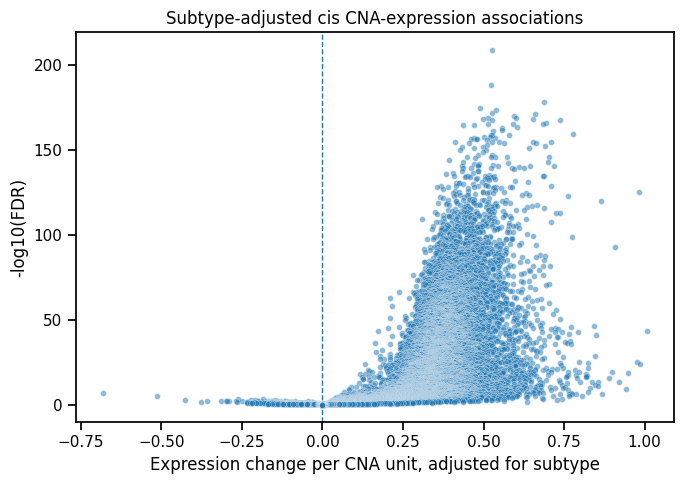

In [12]:
plot_df = cis_results.copy()
plot_df["minus_log10_fdr"] = -np.log10(plot_df["fdr"].clip(lower=1e-300))

plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=plot_df,
    x="coef_cna_adjusted_for_subtype",
    y="minus_log10_fdr",
    alpha=0.5,
    s=18,
)

plt.axvline(0, linestyle="--", linewidth=1)
plt.title("Subtype-adjusted cis CNA-expression associations")
plt.xlabel("Expression change per CNA unit, adjusted for subtype")
plt.ylabel("-log10(FDR)")
plt.tight_layout()

plt.savefig(FIGURES_DIR / "cis_cna_expression_subtype_adjusted_scan.png", dpi=300)
plt.show()

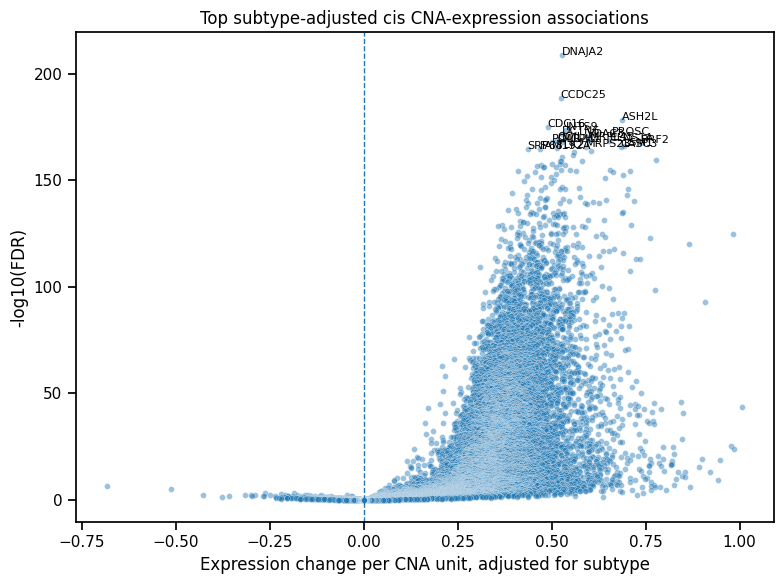

In [13]:
top_label_genes = (
    cis_results
    .sort_values("fdr")
    .head(20)["gene"]
    .tolist()
)

plot_df = cis_results.copy()
plot_df["minus_log10_fdr"] = -np.log10(plot_df["fdr"].clip(lower=1e-300))

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=plot_df,
    x="coef_cna_adjusted_for_subtype",
    y="minus_log10_fdr",
    alpha=0.45,
    s=18,
)

plt.axvline(0, linestyle="--", linewidth=1)

for _, row in plot_df[plot_df["gene"].isin(top_label_genes)].iterrows():
    plt.text(
        row["coef_cna_adjusted_for_subtype"],
        row["minus_log10_fdr"],
        row["gene"],
        fontsize=8,
    )

plt.title("Top subtype-adjusted cis CNA-expression associations")
plt.xlabel("Expression change per CNA unit, adjusted for subtype")
plt.ylabel("-log10(FDR)")
plt.tight_layout()

plt.savefig(FIGURES_DIR / "cis_cna_expression_top_genes_labeled.png", dpi=300)
plt.show()

In [14]:
known_driver_genes = [
    "ERBB2", "CCND1", "MYC", "PTEN", "RB1", "TP53",
    "PIK3CA", "GATA3", "CDH1", "MAP3K1", "BRCA1", "BRCA2"
]

less_obvious_cis_candidates = cis_results[
    (~cis_results["gene"].isin(known_driver_genes)) &
    (cis_results["fdr"] < 0.05) &
    (cis_results["coef_cna_adjusted_for_subtype"].abs() >= 0.25)
].copy()

display(less_obvious_cis_candidates.head(30))

less_obvious_cis_candidates.to_csv(
    TABLES_DIR / "less_obvious_cis_cna_expression_candidates.csv",
    index=False
)

,gene,coef_cna_adjusted_for_subtype,correlation_adjusted_for_subtype,p_value,altered_fraction,amp_fraction,del_fraction,expression_variance,fdr
4203,DNAJA2,0.526660,0.794087,6.466215e-214,0.690112,0.014271,0.012232,0.286326,1.156935e-209
2422,CCDC25,0.524092,0.769900,3.538109e-193,0.668705,0.007136,0.040775,0.304231,3.165192e-189
1057,ASH2L,0.686383,0.756600,7.917996e-183,0.628950,0.114169,0.009174,0.795628,4.722293e-179
2674,CDC16,0.489813,0.751653,3.793792e-179,0.532110,0.014271,0.004077,0.229663,1.696963e-175
7415,INTS9,0.538456,0.749924,6.998536e-178,0.667686,0.004077,0.043833,0.324686,2.504356e-174
3917,DCTN6,0.526664,0.747017,8.927738e-176,0.658512,0.011213,0.036697,0.336173,2.662252e-172
12025,PROSC,0.660042,0.746609,1.751239e-175,0.632008,0.116208,0.011213,0.762125,4.476167e-172
16766,VDAC3,0.594238,0.744961,2.642515e-174,0.588175,0.077472,0.009174,0.534763,5.909985e-171
3283,COIL,0.515445,0.743231,4.456139e-173,0.524975,0.056065,0.000000,0.310262,8.727108e-170
9521,MRPL45,0.601245,0.743176,4.877660e-173,0.538226,0.048930,0.002039,0.458043,8.727108e-170


# 09B — Driver-associated transcriptome scan

In [15]:
n_top_expression_genes = 5000

expression_variance_all = X_expr_log.var(axis=0).sort_values(ascending=False)
top_expression_genes = expression_variance_all.head(n_top_expression_genes).index.tolist()

X_expr_top = X_expr_log[top_expression_genes].copy()

print("Top expression genes for driver-associated scan:", X_expr_top.shape)

Top expression genes for driver-associated scan: (981, 5000)


In [16]:
Y_resid = residualize_matrix(X_expr_top.values, subtype_design)

# Optional standardization of residual expression
Y_resid = (Y_resid - Y_resid.mean(axis=0)) / Y_resid.std(axis=0)

print("Residualized expression matrix:", Y_resid.shape)

Residualized expression matrix: (981, 5000)


In [17]:
driver_events = [
    "TP53_mut",
    "PIK3CA_mut",
    "GATA3_mut",
    "CDH1_mut",
    "MAP3K1_mut",
    "ERBB2_amp",
    "MYC_amp",
    "CCND1_amp",
    "PTEN_del",
    "RB1_del",
]

driver_events = [event for event in driver_events if event in meta_idx.columns]

print("Driver events available:")
print(driver_events)

for event in driver_events:
    print(event, meta_idx[event].value_counts(dropna=False).to_dict())

Driver events available:
['TP53_mut', 'PIK3CA_mut', 'GATA3_mut', 'CDH1_mut', 'MAP3K1_mut', 'ERBB2_amp', 'MYC_amp', 'CCND1_amp', 'PTEN_del', 'RB1_del']
TP53_mut {0: 638, 1: 343}
PIK3CA_mut {0: 639, 1: 342}
GATA3_mut {0: 861, 1: 120}
CDH1_mut {0: 853, 1: 128}
MAP3K1_mut {0: 894, 1: 87}
ERBB2_amp {0: 866, 1: 115}
MYC_amp {0: 828, 1: 153}
CCND1_amp {0: 829, 1: 152}
PTEN_del {0: 931, 1: 50}
RB1_del {0: 941, 1: 40}


In [18]:
driver_scan_results = []

for event in driver_events:
    event_values = meta_idx[event].astype(float).values
    
    n_event = int(np.sum(event_values == 1))
    n_no_event = int(np.sum(event_values == 0))
    
    if n_event < 20 or n_no_event < 20:
        print(f"Skipping {event}: too few samples. event={n_event}, no_event={n_no_event}")
        continue
    
    x_resid = residualize_vector(event_values, subtype_design)
    
    coef, corr, p_values = fast_residual_association(Y_resid, x_resid)
    fdr = benjamini_hochberg(p_values)
    
    event_df = pd.DataFrame({
        "event": event,
        "gene": top_expression_genes,
        "coef_event_adjusted_for_subtype": coef,
        "correlation_adjusted_for_subtype": corr,
        "p_value": p_values,
        "fdr": fdr,
        "n_event": n_event,
        "n_no_event": n_no_event,
    })
    
    event_df = event_df.sort_values(["fdr", "p_value"])
    
    outpath = TABLES_DIR / f"driver_associated_expression_scan_{event}.csv"
    event_df.to_csv(outpath, index=False)
    
    driver_scan_results.append(event_df)
    
    print(event)
    display(event_df.head(10))

driver_scan_all = pd.concat(driver_scan_results, axis=0)

driver_scan_all.to_csv(
    TABLES_DIR / "driver_associated_expression_scan_all_events.csv",
    index=False
)

TP53_mut


,event,gene,coef_event_adjusted_for_subtype,correlation_adjusted_for_subtype,p_value,fdr,n_event,n_no_event
488,TP53_mut,PSAT1,0.778152,0.286245,5.904748e-20,2.952374e-16,343,638
1475,TP53_mut,CBX2,0.721655,0.265462,2.765016e-17,6.912540e-14,343,638
3410,TP53_mut,TNFRSF10C,-0.698309,-0.256874,3.013068e-16,5.021780e-13,343,638
2637,TP53_mut,MID1,0.686803,0.252642,9.468934e-16,1.183617e-12,343,638
3576,TP53_mut,AGBL2,-0.644537,-0.237094,5.309391e-14,5.309391e-11,343,638
3205,TP53_mut,FAM83D,0.640032,0.235437,8.022735e-14,6.379584e-11,343,638
4969,TP53_mut,TMEM101,-0.638855,-0.235004,8.931418e-14,6.379584e-11,343,638
4684,TP53_mut,EDA2R,-0.636231,-0.234039,1.133669e-13,6.601951e-11,343,638
711,TP53_mut,AQP9,0.635711,0.233848,1.188351e-13,6.601951e-11,343,638
1446,TP53_mut,TBC1D9,-0.630392,-0.231891,1.920050e-13,9.600250e-11,343,638


PIK3CA_mut


,event,gene,coef_event_adjusted_for_subtype,correlation_adjusted_for_subtype,p_value,fdr,n_event,n_no_event
96,PIK3CA_mut,CYP4Z2P,0.556091,0.251390,1.323289e-15,6.616445e-12,342,639
4247,PIK3CA_mut,IRS2,-0.537775,-0.243110,1.155738e-14,2.889345e-11,342,639
363,PIK3CA_mut,MYT1,-0.528490,-0.238912,3.363879e-14,5.606465e-11,342,639
444,PIK3CA_mut,PAH,-0.509498,-0.230327,2.808868e-13,3.511085e-10,342,639
1417,PIK3CA_mut,SH3RF2,0.464920,0.210174,2.953860e-11,2.953860e-08,342,639
516,PIK3CA_mut,CDSN,0.463073,0.209339,3.547582e-11,2.956319e-08,342,639
1556,PIK3CA_mut,RAB39B,-0.459917,-0.207913,4.842658e-11,3.459041e-08,342,639
710,PIK3CA_mut,WDR17,-0.458410,-0.207232,5.613734e-11,3.508584e-08,342,639
2360,PIK3CA_mut,FAM46B,0.451705,0.204200,1.077010e-10,5.742579e-08,342,639
251,PIK3CA_mut,NAT1,0.451038,0.203899,1.148516e-10,5.742579e-08,342,639


GATA3_mut


...

,event,gene,coef_event_adjusted_for_subtype,correlation_adjusted_for_subtype,p_value,fdr,n_event,n_no_event
2915,CCND1_amp,CCND1,1.248157,0.442004,3.540885e-48,1.770442e-44,152,829
3791,CCND1_amp,ANO1,0.928305,0.328736,3.745293e-26,9.363233e-23,152,829
4944,CCND1_amp,E2F1,0.681744,0.241423,1.779685e-14,2.966142e-11,152,829
3672,CCND1_amp,TROAP,0.675046,0.239051,3.248099e-14,4.060124e-11,152,829
2996,CCND1_amp,C2orf48,0.666523,0.236033,6.918689e-14,6.918689e-11,152,829
3738,CCND1_amp,KIF18B,0.661498,0.234253,1.075230e-13,8.960248e-11,152,829
3649,CCND1_amp,FOXM1,0.653553,0.231440,2.143300e-13,1.530929e-10,152,829
4784,CCND1_amp,GTSE1,0.646624,0.228986,3.883028e-13,2.426892e-10,152,829
4240,CCND1_amp,FGF19,0.622261,0.220359,2.973002e-12,1.651668e-09,152,829
4710,CCND1_amp,ESPL1,0.619860,0.219508,3.616994e-12,1.808497e-09,152,829


PTEN_del


,event,gene,coef_event_adjusted_for_subtype,correlation_adjusted_for_subtype,p_value,fdr,n_event,n_no_event
122,PTEN_del,CASP14,0.735445,0.156930,7.829247e-07,0.003915,50,931
1129,PTEN_del,IL22RA2,0.694022,0.148092,3.190513e-06,0.007976,50,931
3339,PTEN_del,PRDM13,-0.669783,-0.142919,6.998211e-06,0.011664,50,931
1010,PTEN_del,C21orf88,0.635091,0.135517,2.055680e-05,0.025603,50,931
83,PTEN_del,LBP,0.627378,0.133871,2.592856e-05,0.025603,50,931
2976,PTEN_del,MT1H,0.621601,0.132638,3.079889e-05,0.025603,50,931
2389,PTEN_del,IGF1R,-0.616467,-0.131543,3.584443e-05,0.025603,50,931
4212,PTEN_del,SP6,0.603294,0.128732,5.261529e-05,0.030990,50,931
4107,PTEN_del,FGF11,0.601265,0.128299,5.578152e-05,0.030990,50,931
1575,PTEN_del,PSORS1C2,0.589466,0.125781,7.806659e-05,0.037352,50,931


RB1_del


,event,gene,coef_event_adjusted_for_subtype,correlation_adjusted_for_subtype,p_value,fdr,n_event,n_no_event
2759,RB1_del,ZBTB8B,0.929929,0.180886,1.160565e-08,0.000058,40,941
1769,RB1_del,CDKN2A,0.791890,0.154035,1.251344e-06,0.003128,40,941
1633,RB1_del,TMEM108,0.765820,0.148964,2.787146e-06,0.004645,40,941
2915,RB1_del,CCND1,-0.706878,-0.137499,1.548682e-05,0.013857,40,941
2635,RB1_del,SPSB4,0.705834,0.137296,1.594564e-05,0.013857,40,941
3701,RB1_del,AGBL4,0.702638,0.136674,1.743192e-05,0.013857,40,941
940,RB1_del,CDCA7,0.697101,0.135597,2.032299e-05,0.013857,40,941
873,RB1_del,OXGR1,0.693122,0.134823,2.267684e-05,0.013857,40,941
4591,RB1_del,CCNE2,0.688826,0.133988,2.550735e-05,0.013857,40,941
1973,RB1_del,MYB,0.685780,0.133395,2.771498e-05,0.013857,40,941


In [19]:
driver_scan_summary = (
    driver_scan_all
    .assign(significant=lambda d: d["fdr"] < 0.05)
    .groupby("event")
    .agg(
        n_tested_genes=("gene", "count"),
        n_significant=("significant", "sum"),
        min_fdr=("fdr", "min"),
        max_abs_coef=("coef_event_adjusted_for_subtype", lambda x: np.nanmax(np.abs(x))),
    )
    .reset_index()
    .sort_values("n_significant", ascending=False)
)

display(driver_scan_summary)

driver_scan_summary.to_csv(
    TABLES_DIR / "driver_associated_expression_scan_summary.csv",
    index=False
)

,event,n_tested_genes,n_significant,min_fdr,max_abs_coef
1,CDH1_mut,5000,1773,2.067431e-75,1.704457
9,TP53_mut,5000,1698,2.952374e-16,0.778152
6,PIK3CA_mut,5000,1387,6.616445e-12,0.556091
3,GATA3_mut,5000,942,1.744252e-16,0.902403
2,ERBB2_amp,5000,434,2.555791e-119,2.446265
0,CCND1_amp,5000,295,1.770442e-44,1.248157
4,MAP3K1_mut,5000,176,1.782748e-06,0.711499
5,MYC_amp,5000,95,2.879687e-05,0.530913
8,RB1_del,5000,21,5.802823e-05,0.929929
7,PTEN_del,5000,16,3.914623e-03,0.735445


Top genes selected for heatmap: 78


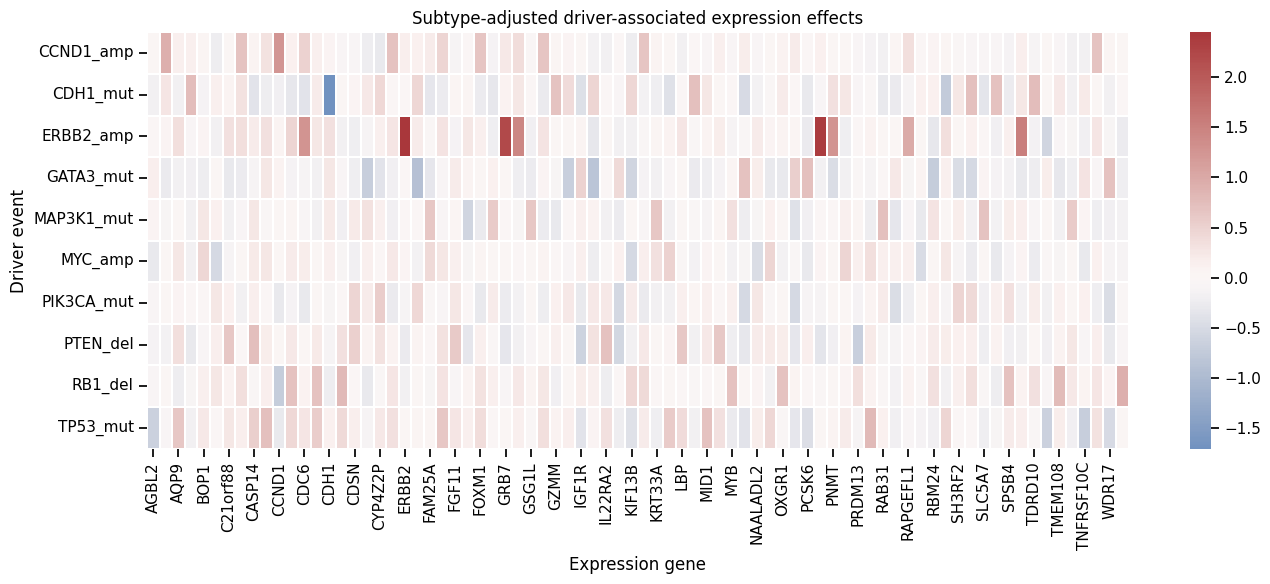

In [20]:
top_genes_by_event = []

for event in driver_scan_all["event"].unique():
    top = (
        driver_scan_all[driver_scan_all["event"] == event]
        .sort_values("fdr")
        .head(8)["gene"]
        .tolist()
    )
    top_genes_by_event.extend(top)

top_genes_by_event = list(dict.fromkeys(top_genes_by_event))

print("Top genes selected for heatmap:", len(top_genes_by_event))

heatmap_matrix = (
    driver_scan_all[driver_scan_all["gene"].isin(top_genes_by_event)]
    .pivot_table(
        index="event",
        columns="gene",
        values="coef_event_adjusted_for_subtype",
    )
)

plt.figure(figsize=(14, 6))
sns.heatmap(
    heatmap_matrix,
    cmap="vlag",
    center=0,
    linewidths=0.2,
)

plt.title("Subtype-adjusted driver-associated expression effects")
plt.xlabel("Expression gene")
plt.ylabel("Driver event")
plt.tight_layout()

plt.savefig(FIGURES_DIR / "driver_associated_expression_effects_heatmap.png", dpi=300)
plt.show()

heatmap_matrix.to_csv(
    TABLES_DIR / "driver_associated_expression_effects_heatmap_matrix.csv"
)

# 09C — Subtype-adjusted co-expression modules

In [21]:
n_network_genes = 500

network_genes = expression_variance_all.head(n_network_genes).index.tolist()
X_network = X_expr_log[network_genes].copy()

Y_network_resid = residualize_matrix(X_network.values, subtype_design)

# z-score residuals gene-wise
Y_network_resid = (
    Y_network_resid - Y_network_resid.mean(axis=0)
) / Y_network_resid.std(axis=0)

print("Network residual matrix:", Y_network_resid.shape)

Network residual matrix: (981, 500)


In [22]:
corr_matrix = np.corrcoef(Y_network_resid.T)

corr_df = pd.DataFrame(
    corr_matrix,
    index=network_genes,
    columns=network_genes,
)

display(corr_df.iloc[:5, :5])

corr_df.to_csv(TABLES_DIR / "subtype_adjusted_coexpression_correlation_matrix_top_genes.csv")

,CLEC3A,CPB1,SCGB2A2,SCGB1D2,TFF1
CLEC3A,1.000000,0.141809,0.152863,0.156286,0.092020
CPB1,0.141809,1.000000,-0.053798,0.000102,0.043567
SCGB2A2,0.152863,-0.053798,1.000000,0.937019,0.293301
SCGB1D2,0.156286,0.000102,0.937019,1.000000,0.271554
TFF1,0.092020,0.043567,0.293301,0.271554,1.000000


/Users/rubensiok/tcga-brca-translational-stratification/.venv/lib/python3.13/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/Users/rubensiok/tcga-brca-translational-stratification/.venv/lib/python3.13/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


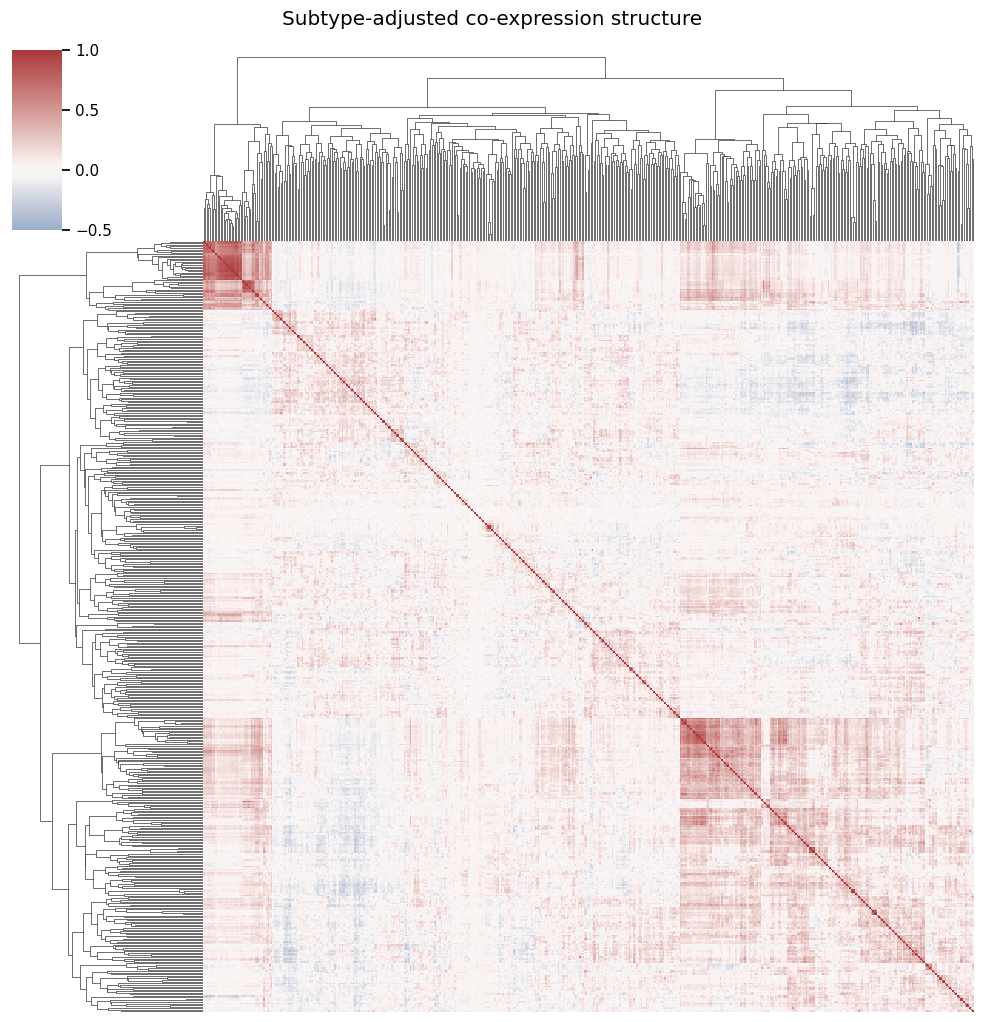

In [23]:
g = sns.clustermap(
    corr_df,
    cmap="vlag",
    center=0,
    figsize=(10, 10),
    xticklabels=False,
    yticklabels=False,
)

g.fig.suptitle("Subtype-adjusted co-expression structure", y=1.02)

g.savefig(
    FIGURES_DIR / "subtype_adjusted_coexpression_clustermap.png",
    dpi=300,
)

In [24]:
# Convert correlation to distance
distance_matrix = 1 - corr_matrix
np.fill_diagonal(distance_matrix, 0)

# Numerical safety
distance_matrix = np.clip(distance_matrix, 0, 2)

condensed_distance = squareform(distance_matrix, checks=False)

Z = linkage(condensed_distance, method="average")

module_labels = fcluster(Z, t=8, criterion="maxclust")

module_df = pd.DataFrame({
    "gene": network_genes,
    "module": module_labels,
})

display(module_df["module"].value_counts().sort_index())

module_df.to_csv(TABLES_DIR / "subtype_adjusted_coexpression_modules.csv", index=False)

module
1    132
2     17
3     25
4      1
5     16
6    306
7      2
8      1
Name: count, dtype: int64

In [25]:
module_scores = pd.DataFrame(index=meta_idx.index)

Y_network_resid_df = pd.DataFrame(
    Y_network_resid,
    index=meta_idx.index,
    columns=network_genes,
)

for module in sorted(module_df["module"].unique()):
    genes = module_df.loc[module_df["module"] == module, "gene"].tolist()
    
    if len(genes) < 3:
        continue
    
    module_scores[f"module_{module}"] = Y_network_resid_df[genes].mean(axis=1)

display(module_scores.head())

module_scores.to_csv(TABLES_DIR / "subtype_adjusted_module_scores.csv")

,,module_1,module_2,module_3,module_5,module_6
SAMPLE_ID_15,PATIENT_ID_12,,,,,
TCGA-3C-AAAU-01,TCGA-3C-AAAU,0.493547,0.197992,-0.500417,-0.328433,-0.518564
TCGA-3C-AALI-01,TCGA-3C-AALI,-0.029039,-0.039397,0.411665,-0.020640,-0.067335
TCGA-3C-AALJ-01,TCGA-3C-AALJ,-0.140330,0.263886,-0.132411,-0.033453,-0.164312
TCGA-3C-AALK-01,TCGA-3C-AALK,0.079720,-0.034045,0.264134,0.176785,0.317003
TCGA-4H-AAAK-01,TCGA-4H-AAAK,-0.181316,-0.075720,0.508149,1.089358,0.017701


In [26]:
module_event_rows = []

for event in driver_events:
    event_values = meta_idx[event].astype(float).values
    
    n_event = int(np.sum(event_values == 1))
    n_no_event = int(np.sum(event_values == 0))
    
    if n_event < 20 or n_no_event < 20:
        continue
    
    event_resid = residualize_vector(event_values, subtype_design)
    
    for module_col in module_scores.columns:
        score = module_scores[module_col].values
        
        if np.std(score) == 0 or np.std(event_resid) == 0:
            continue
        
        r, p_value = pearsonr(event_resid, score)
        
        module_event_rows.append({
            "event": event,
            "module": module_col,
            "correlation_adjusted_for_subtype": r,
            "p_value": p_value,
            "n_event": n_event,
            "n_no_event": n_no_event,
        })

module_event_df = pd.DataFrame(module_event_rows)
module_event_df["fdr"] = benjamini_hochberg(module_event_df["p_value"].values)

module_event_df = module_event_df.sort_values(["fdr", "p_value"])

display(module_event_df.head(30))

module_event_df.to_csv(
    TABLES_DIR / "subtype_adjusted_module_event_associations.csv",
    index=False
)

,event,module,correlation_adjusted_for_subtype,p_value,n_event,n_no_event,fdr
0,TP53_mut,module_1,-0.223291,1.502573e-12,343,638,7.512863e-11
12,GATA3_mut,module_3,-0.163220,2.744693e-07,120,861,6.861733e-06
8,PIK3CA_mut,module_5,0.153207,1.428625e-06,342,639,2.381042e-05
9,PIK3CA_mut,module_6,0.143240,6.671095e-06,342,639,8.338869e-05
4,TP53_mut,module_6,0.127327,6.355850e-05,343,638,5.721803e-04
37,CCND1_amp,module_3,0.126748,6.866164e-05,152,829,5.721803e-04
19,CDH1_mut,module_6,0.119681,1.717816e-04,128,853,1.227011e-03
23,MAP3K1_mut,module_5,0.114513,3.257481e-04,87,894,2.035926e-03
25,ERBB2_amp,module_1,-0.109968,5.598009e-04,115,866,3.110005e-03
31,MYC_amp,module_2,0.106039,8.797735e-04,153,828,4.398868e-03


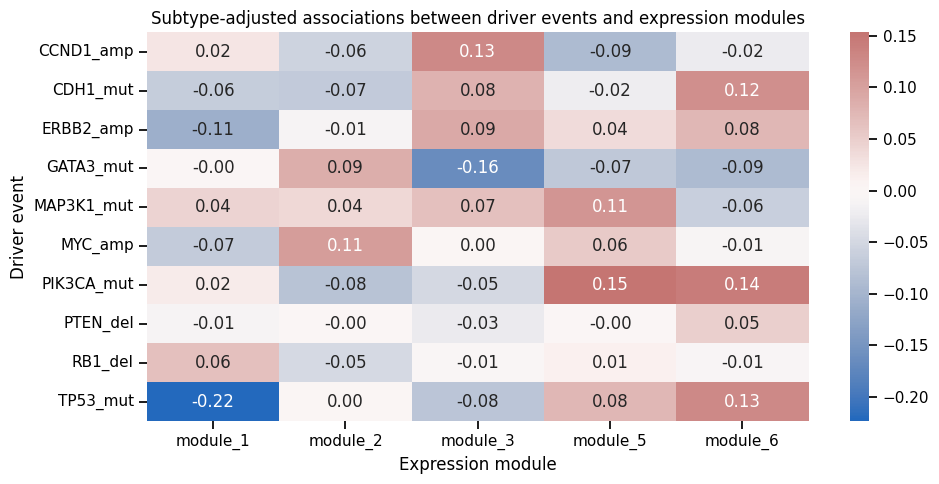

In [27]:
module_event_matrix = (
    module_event_df
    .pivot_table(
        index="event",
        columns="module",
        values="correlation_adjusted_for_subtype",
    )
)

plt.figure(figsize=(10, 5))
sns.heatmap(
    module_event_matrix,
    cmap="vlag",
    center=0,
    annot=True,
    fmt=".2f",
)

plt.title("Subtype-adjusted associations between driver events and expression modules")
plt.xlabel("Expression module")
plt.ylabel("Driver event")
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "subtype_adjusted_module_event_associations_heatmap.png",
    dpi=300,
)

plt.show()

In [28]:
module_gene_summary = (
    module_df
    .groupby("module")["gene"]
    .apply(lambda genes: ", ".join(list(genes)[:30]))
    .reset_index()
)

display(module_gene_summary)

module_gene_summary.to_csv(
    TABLES_DIR / "subtype_adjusted_coexpression_module_gene_summary.csv",
    index=False
)

,module,gene
0,1,"CLEC3A, CPB1, ANKRD30A, KCNJ3, SERPINA6, SLC30..."
1,2,"MSLN, EEF1A2, PPP2R2C, TNNT1, DIO1, KNDC1, ACT..."
2,3,"DHRS2, COL2A1, C1orf64, PVALB, NXPH1, C10orf82..."
3,4,GSTT1
4,5,"CST1, CLIC6, MMP1, NDP, CST4, MMP13, CD177, EP..."
5,6,"SCGB2A2, SCGB1D2, TFF1, PIP, S100A7, MUCL1, CY..."
6,7,"TBC1D3G, AFAP1-AS1"
7,8,GSTM1


In [29]:
for module in sorted(module_df["module"].unique()):
    genes = module_df.loc[module_df["module"] == module, "gene"].tolist()
    print(f"\nModule {module} — n={len(genes)}")
    print(", ".join(genes[:40]))


Module 1 — n=132
CLEC3A, CPB1, ANKRD30A, KCNJ3, SERPINA6, SLC30A8, VSTM2A, GP2, GRIA2, SYT13, BMPR1B, CST9, CYP2A6, NPY1R, GFRA1, PGR, CGA, LRP2, KCNC2, SERPINA11, CBLN2, PTPRT, CYP4F8, BEX1, SLC6A4, SLITRK6, SYT9, ESR1, CHAD, GRPR, ANKRD30B, CDC20B, CST5, SORCS1, ASCL1, PDZK1, NBPF4, ABCC8, LRP1B, SCUBE2

Module 2 — n=17
MSLN, EEF1A2, PPP2R2C, TNNT1, DIO1, KNDC1, ACTL8, C16orf89, AKR7A3, PCSK1N, THRSP, C19orf33, TLX1, FAM83E, TTC36, TSIX, TNNI3

Module 3 — n=25
DHRS2, COL2A1, C1orf64, PVALB, NXPH1, C10orf82, KLHDC7A, WNK4, ALB, MS4A15, FREM2, DLK1, BCAS1, GLDC, ATRNL1, IGDCC3, SYNPO2L, GPC1-AS1, HPX, ADCY5, CACNG4, CTNND2, CECR2, ADAMTS19, AFP

Module 4 — n=1
GSTT1

Module 5 — n=16
CST1, CLIC6, MMP1, NDP, CST4, MMP13, CD177, EPYC, PCDH10, SHISA2, COL11A1, MKX, MMP10, TPSD1, MAOB, SERPINB2

Module 6 — n=306
SCGB2A2, SCGB1D2, TFF1, PIP, S100A7, MUCL1, CYP4Z1, PRAME, AGR3, HMGCS2, TFAP2B, MUC6, UGT2B11, TAT, ADH1B, ADIPOQ, CALML5, MYBPC1, GABRP, MUC5B, CEACAM5, KRT14, TFF3, SOX10, KRT5,

## Interpretation

This notebook performs exploratory subtype-adjusted multi-omic discovery.

The cis CNA-expression scan identifies genes whose expression is associated with their own copy-number status after adjusting for molecular subtype. Known events such as ERBB2 amplification are expected positive controls, but less obvious candidates may suggest additional dosage-sensitive genes.

The driver-associated transcriptome scan asks whether selected genomic events are associated with broader expression changes beyond subtype effects. These associations may reflect downstream pathway activity, co-occurring alterations, or tumour biology not fully captured by subtype labels.

The co-expression module analysis removes the major subtype effect before estimating gene-gene correlations. This helps identify residual expression modules that may be associated with specific driver events.

All results are hypothesis-generating. They do not establish causality or clinical actionability, but they provide candidate molecular patterns for further validation.